## Best Optimization CV - Employer Bee Algo 2 + Onlooker Bee Algo 3

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Methodology.ABC_Testing import abc_testing

In [2]:
fold_id = 2
mod = f"Grid_Optimization_Fold_{fold_id}"

gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()
gallstone_dataset.cross_validate_test(5)

x_train, y_train, x_test, y_test = gallstone_dataset.fold_split[fold_id]

features_size = x_train.shape[1]

In [3]:
best_lambda_config = GlobalSetting.get_config_by_type("Grid_Optimization")
best_lambda_hidden_size = best_lambda_config["Hidden_Nodes"] if best_lambda_config else None
best_lambda_lambda_value = best_lambda_config["Lambda_Value"] if best_lambda_config else None

In [4]:
abc_r_elm_cv  = ArtificialBeeColonyElmCV(
    features_size       = features_size,
    hidden_size         = best_lambda_hidden_size,
    activation_function = GlobalSetting.sigmoid             ,
    regularization_lambda=best_lambda_lambda_value           ,
    fitness_function    = GlobalSetting.evaluation_function ,
    solution_size       = GlobalSetting.solution_size       ,
    trial_limit         = GlobalSetting.trial_limit         ,
    max_iteration       = GlobalSetting.max_iteration
)
abc_r_elm_cv.employed_bee_apply_algo3()
abc_r_elm_cv.onlooker_bee_apply_algo2()

In [5]:
results_df , convergence_df , scout_df = abc_testing(abc_r_elm_cv, x_train, y_train, x_test, y_test)
results_df.describe()


Running simulation for Seed: 161...
Iteration 003 complete | Duration: 0.0913s | Scout Triggers: 3 | Best Fitness: 0.752865

Running simulation for Seed: 162...
Iteration 003 complete | Duration: 0.0768s | Scout Triggers: 3 | Best Fitness: 0.737018

Running simulation for Seed: 163...
Iteration 003 complete | Duration: 0.0855s | Scout Triggers: 5 | Best Fitness: 0.755313

Running simulation for Seed: 164...
Iteration 003 complete | Duration: 0.0839s | Scout Triggers: 4 | Best Fitness: 0.743347

Running simulation for Seed: 165...
Iteration 003 complete | Duration: 0.0751s | Scout Triggers: 3 | Best Fitness: 0.747828

Running simulation for Seed: 166...
Iteration 003 complete | Duration: 0.0980s | Scout Triggers: 4 | Best Fitness: 0.745723

Running simulation for Seed: 167...
Iteration 003 complete | Duration: 0.0983s | Scout Triggers: 5 | Best Fitness: 0.773115

Running simulation for Seed: 168...
Iteration 003 complete | Duration: 0.0874s | Scout Triggers: 5 | Best Fitness: 0.748379


,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.781250,0.780491,0.784375,0.784555,0.778125,0.781564,0.783043,0.781250,0.563769,175.500000
std,0.033336,0.035988,0.050155,0.041609,0.044460,0.034639,0.042669,0.033336,0.066968,8.803408
min,0.718750,0.705882,0.687500,0.722222,0.687500,0.727273,0.705128,0.718750,0.438357,161.000000
25%,0.765625,0.757576,0.750000,0.750000,0.750000,0.754098,0.750000,0.765625,0.531510,168.250000
50%,0.781250,0.784749,0.781250,0.784564,0.781250,0.778685,0.783707,0.781250,0.563051,175.500000
75%,0.796875,0.803115,0.812500,0.806452,0.812500,0.800000,0.807453,0.796875,0.594040,182.750000
max,0.843750,0.862069,0.906250,0.888889,0.875000,0.848485,0.878788,0.843750,0.688847,190.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_Fold_2_MCC.png


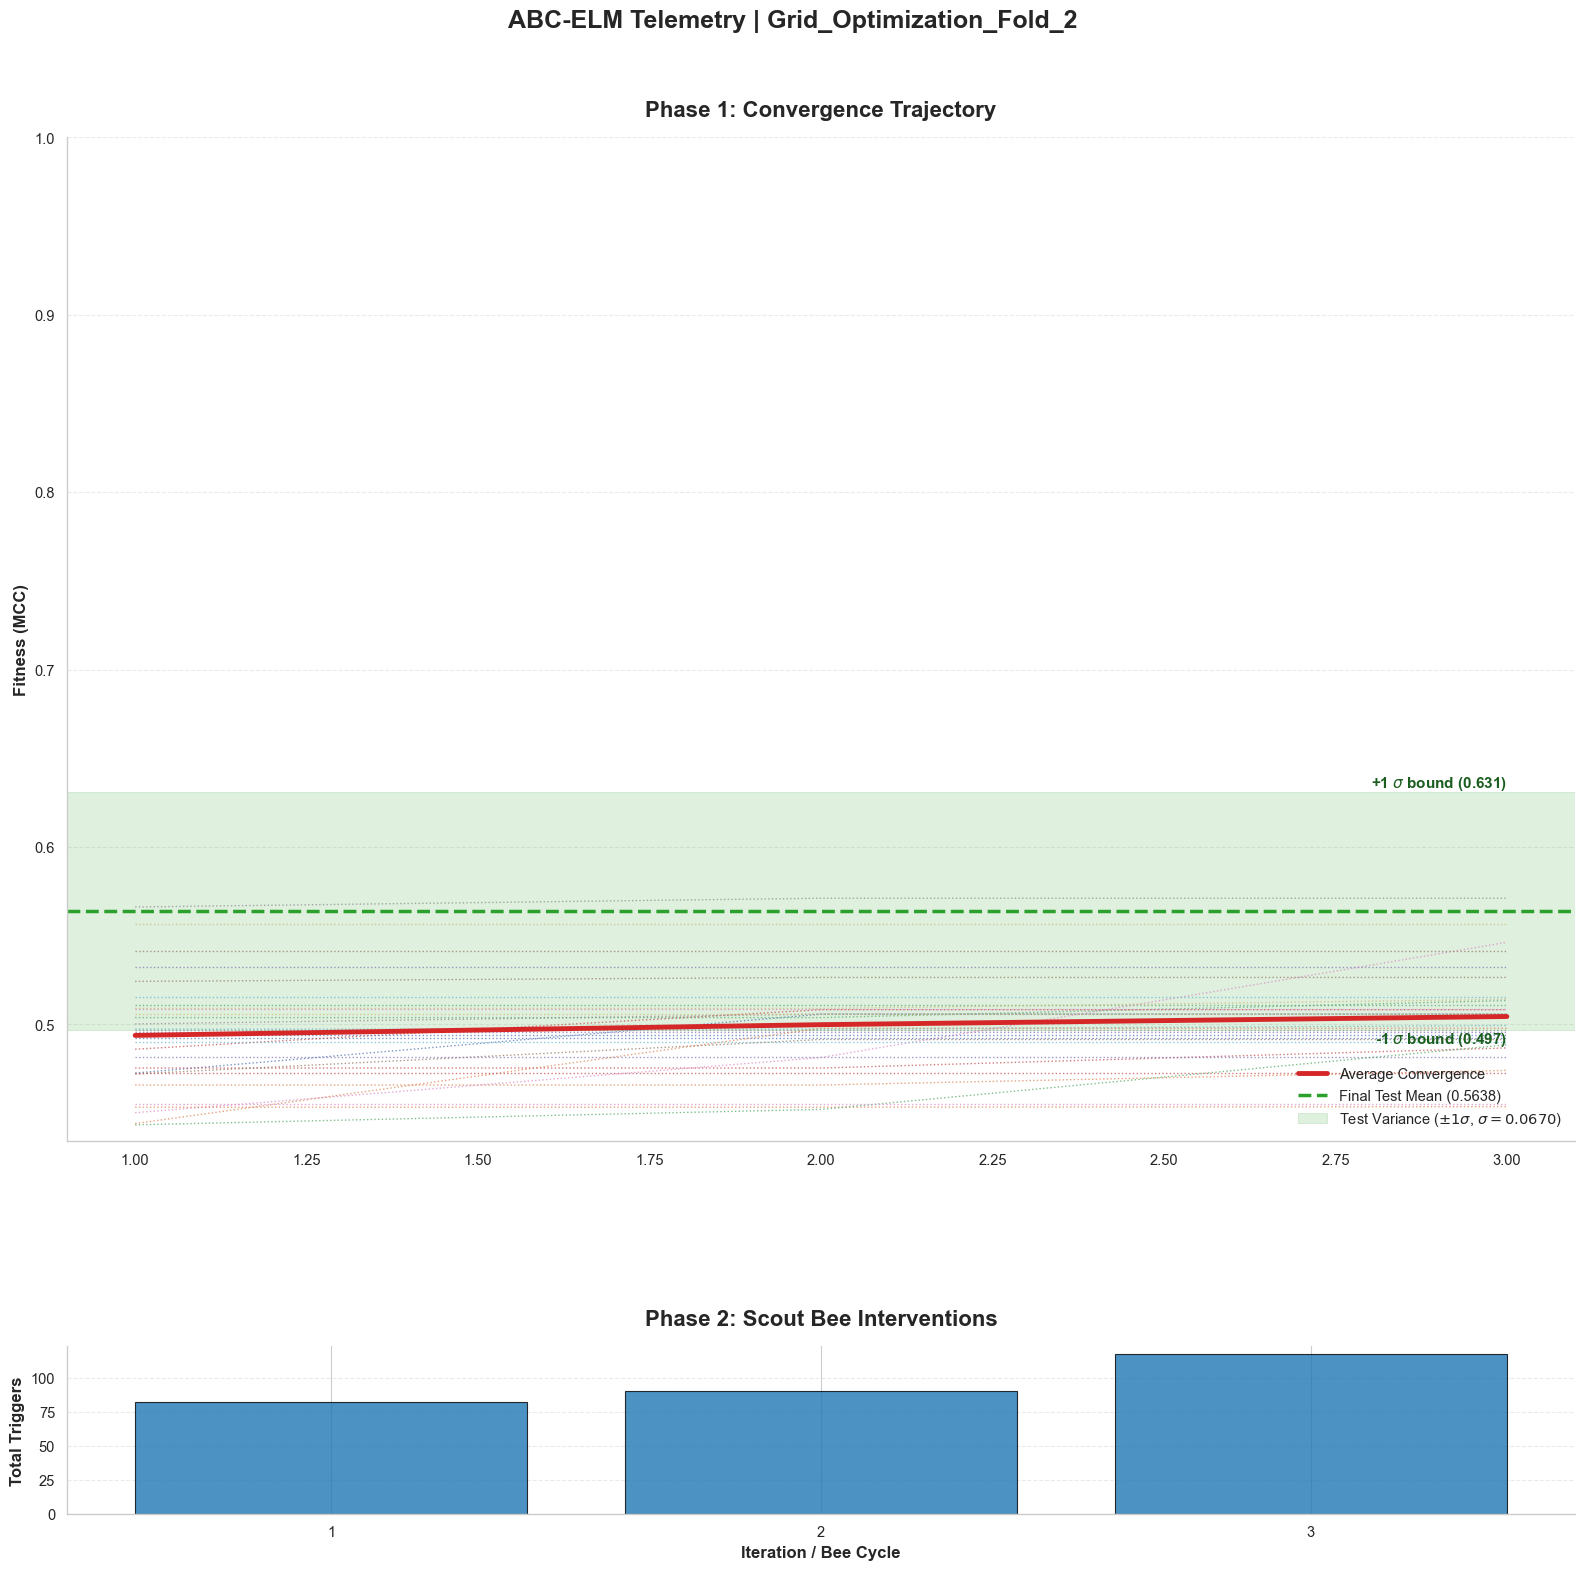

In [6]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,mod,results_df=results_df,is_final_record=True)

In [7]:
GlobalSetting.save_dataframe_to_record(results_df, f"ABC_{mod}_Results.csv")
GlobalSetting.save_dataframe_to_record(convergence_df, f'ABC_{mod}_Convergence.csv')
GlobalSetting.save_dataframe_to_record(scout_df, f'ABC_{mod}_Scout_History.csv')

[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_2_Results.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_2_Convergence.csv
[I/O Trace] Record exported successfully: ../../Storage/Record\ABC_Grid_Optimization_Fold_2_Scout_History.csv
